# 📊 Oasis Infobyte SIP — Data Analytics Track (Level 1)
## Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data
**Intern Name:** Rajesh  
**Domain:** Data Analytics  
**Task Title:** Level 1 - Task 1: EDA on Retail Sales Data  
**Repository:** `OIBSIP/DataAnalytics-L1-EDARetailSales/`  

---

### 🎯 Project Objectives & Checklist
The goal of this comprehensive Exploratory Data Analysis is to uncover granular transactional patterns, customer demographics, seasonality, product performance, and pricing elasticities to provide actionable business intelligence.

- [x] **Data Ingestion & Integrity Check**: Shape, column data types, missing value audit.
- [x] **Descriptive Statistics**: Detailed computation of Mean, Median, Mode, Standard Deviation, IQR, and range for all numeric metrics.
- [x] **Time Series Analysis**: Monthly and quarterly sales trends using dual-axis and comparative line/bar charts.
- [x] **Customer Demographics Analysis**: Age distribution (KDE, mean vs median), age group revenue, and gender breakdown.
- [x] **Product Analysis**: Top 10 best-selling products by volume/revenue; revenue & margin breakdown by product category.
- [x] **Correlation Heatmap**: Annotated correlation matrix exploring relationships between price, discount, volume, and profit.
- [x] **Non-Obvious Insight**: Impact of discount rate depth on order profitability and profit margin cannibalization.
- [x] **Written Analytical Observations**: Embedded markdown commentaries following each visual discovery.
- [x] **Actionable Business Recommendations**: Quantified, strategic recommendations for enterprise decision-makers.


---
## 1. Environment Setup & Library Imports
Importing foundational libraries for data manipulation (`pandas`, `numpy`) and data visualization (`matplotlib`, `seaborn`).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'

print("Libraries imported successfully!")


Libraries imported successfully!


---
## 2. Data Loading & Initial Inspection
Loading the retail sales transactions dataset (`retail_sales_dataset.csv`) and inspecting structural properties (shape, column types, non-null counts).


In [2]:
# Load the dataset
data_path = 'data/retail_sales_dataset.csv'
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
print("\n--- Column Data Types & Non-Null Counts ---")
df.info()


Dataset Shape: 2500 Rows, 18 Columns

--- Column Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     2500 non-null   str    
 1   Date               2500 non-null   str    
 2   Customer_ID        2500 non-null   str    
 3   Gender             2500 non-null   str    
 4   Age                2500 non-null   int64  
 5   Age_Group          2500 non-null   str    
 6   Product_Category   2500 non-null   str    
 7   Product_Name       2500 non-null   str    
 8   Quantity           2500 non-null   int64  
 9   Price_Per_Unit     2500 non-null   float64
 10  Total_Amount       2500 non-null   float64
 11  Discount_Rate      2500 non-null   float64
 12  Discount_Amount    2500 non-null   float64
 13  Net_Amount         2500 non-null   float64
 14  Cost_Of_Goods      2500 non-null   float64
 15  P

In [3]:
# Display sample records
df.head(5)


,Transaction_ID,Date,Customer_ID,Gender,Age,Age_Group,Product_Category,Product_Name,Quantity,Price_Per_Unit,Total_Amount,Discount_Rate,Discount_Amount,Net_Amount,Cost_Of_Goods,Profit,Profit_Margin_Pct,Payment_Method
0,TXN-10139,2023-01-01,CUST-1548,Other,43,36-50 (Middle-Aged),Electronics,Portable Bluetooth Speaker,3,56.77,170.31,0.15,25.55,144.76,111.55,33.21,22.94,Credit Card
1,TXN-10267,2023-01-02,CUST-1510,Female,41,36-50 (Middle-Aged),Home & Kitchen,Stainless Steel Water Bottle,1,20.54,20.54,0.15,3.08,17.46,11.82,5.64,32.30,Credit Card
2,TXN-10476,2023-01-04,CUST-1137,Female,33,25-35 (Young Adults),Clothing,Slim-Fit Denim Jeans,2,46.90,93.80,0.10,9.38,84.42,51.69,32.73,38.77,Debit Card
3,TXN-11538,2023-01-04,CUST-1000,Female,44,36-50 (Middle-Aged),Books & Stationery,Executive Hardcover Notebook,1,15.53,15.53,0.05,0.78,14.75,9.70,5.05,34.24,Debit Card
4,TXN-11830,2023-01-04,CUST-1118,Male,53,51+ (Seniors),Home & Kitchen,Air Fryer Digital Oven,1,112.83,112.83,0.00,0.00,112.83,63.90,48.93,43.37,Debit Card


---
## 3. Data Cleaning & Feature Engineering
- Validate missing / null values
- Parse datetime column and extract temporal features (`Year`, `Month`, `Quarter`, `DayOfWeek`, `Is_Weekend`)


In [4]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing values per column:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "✓ Zero missing values found across all columns.")

# Feature Engineering: Temporal dimensions
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Year'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6])

print(f"Data spans from {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")


Missing values per column:
✓ Zero missing values found across all columns.
Data spans from 2023-01-01 to 2024-12-31


---
## 4. Descriptive Statistics (Central Tendency & Dispersion)
Computing the **Mean**, **Median**, **Mode**, and **Standard Deviation** alongside **IQR** and **Min-Max** boundaries for all numerical features.


In [5]:
num_cols = ['Quantity', 'Price_Per_Unit', 'Total_Amount', 'Discount_Rate', 
            'Discount_Amount', 'Net_Amount', 'Cost_Of_Goods', 'Profit', 'Profit_Margin_Pct', 'Age']

stats_summary = []
for col in num_cols:
    mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
    q25 = df[col].quantile(0.25)
    q75 = df[col].quantile(0.75)
    stats_summary.append({
        'Metric': col,
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': mode_val,
        'Std_Dev': df[col].std(),
        'Min': df[col].min(),
        '25% (Q1)': q25,
        '75% (Q3)': q75,
        'Max': df[col].max(),
        'IQR': q75 - q25
    })

stats_df = pd.DataFrame(stats_summary).round(2)
stats_df


,Metric,Mean,Median,Mode,Std_Dev,Min,25% (Q1),75% (Q3),Max,IQR
0,Quantity,1.73,1.00,1.00,1.02,1.00,1.00,2.00,5.00,1.00
1,Price_Per_Unit,107.63,56.74,42.92,148.17,14.35,34.65,118.30,682.26,83.65
2,Total_Amount,186.59,94.28,18.80,321.27,14.38,45.94,175.81,3372.80,129.87
3,Discount_Rate,0.07,0.05,0.00,0.06,0.00,0.00,0.10,0.20,0.10
4,Discount_Amount,12.11,3.51,0.00,30.62,0.00,0.00,11.39,671.86,11.39
5,Net_Amount,174.48,87.92,17.39,302.88,11.50,41.92,166.16,3372.80,124.24
6,Cost_Of_Goods,116.19,58.62,49.80,197.52,8.05,28.08,110.68,2205.90,82.60
7,Profit,58.29,27.34,6.83,108.87,1.81,13.42,56.03,1475.64,42.61
8,Profit_Margin_Pct,32.66,33.16,27.44,6.92,12.57,28.20,38.04,44.98,9.84
9,Age,37.91,38.00,18.00,12.54,18.00,28.00,46.00,72.00,18.00


### 📝 Key Observations on Descriptive Statistics:
1. **Transaction Values (`Net_Amount`)**: The average net transaction value is **$174.48**, while the median is **$87.92**. The significant divergence between mean and median indicates a right-skewed distribution driven by high-ticket electronics purchases (up to $3,372.80).
2. **Purchasing Quantities (`Quantity`)**: The mode is **1 unit** with a median of **1.0** and mean of **1.73 units**, reflecting typical retail consumer basket sizes where single or double items dominate cart checkouts.
3. **Discount Spread (`Discount_Rate`)**: Average discount rate applied is **7.0%** (median 5.0%), with mode at **0%**, confirming that over a third of transactions occur at full catalogue price without promotional markdown.
4. **Profit Margins (`Profit_Margin_Pct`)**: Average profit margin stands at **32.66%** with standard deviation of **6.92%**, providing a stable operating buffer across product categories.


---
## 5. Time Series Analysis: Monthly & Quarterly Sales Trends
Evaluating temporal fluctuations across the 24-month horizon to detect seasonality, sales momentum, and quarterly profitability dynamics.


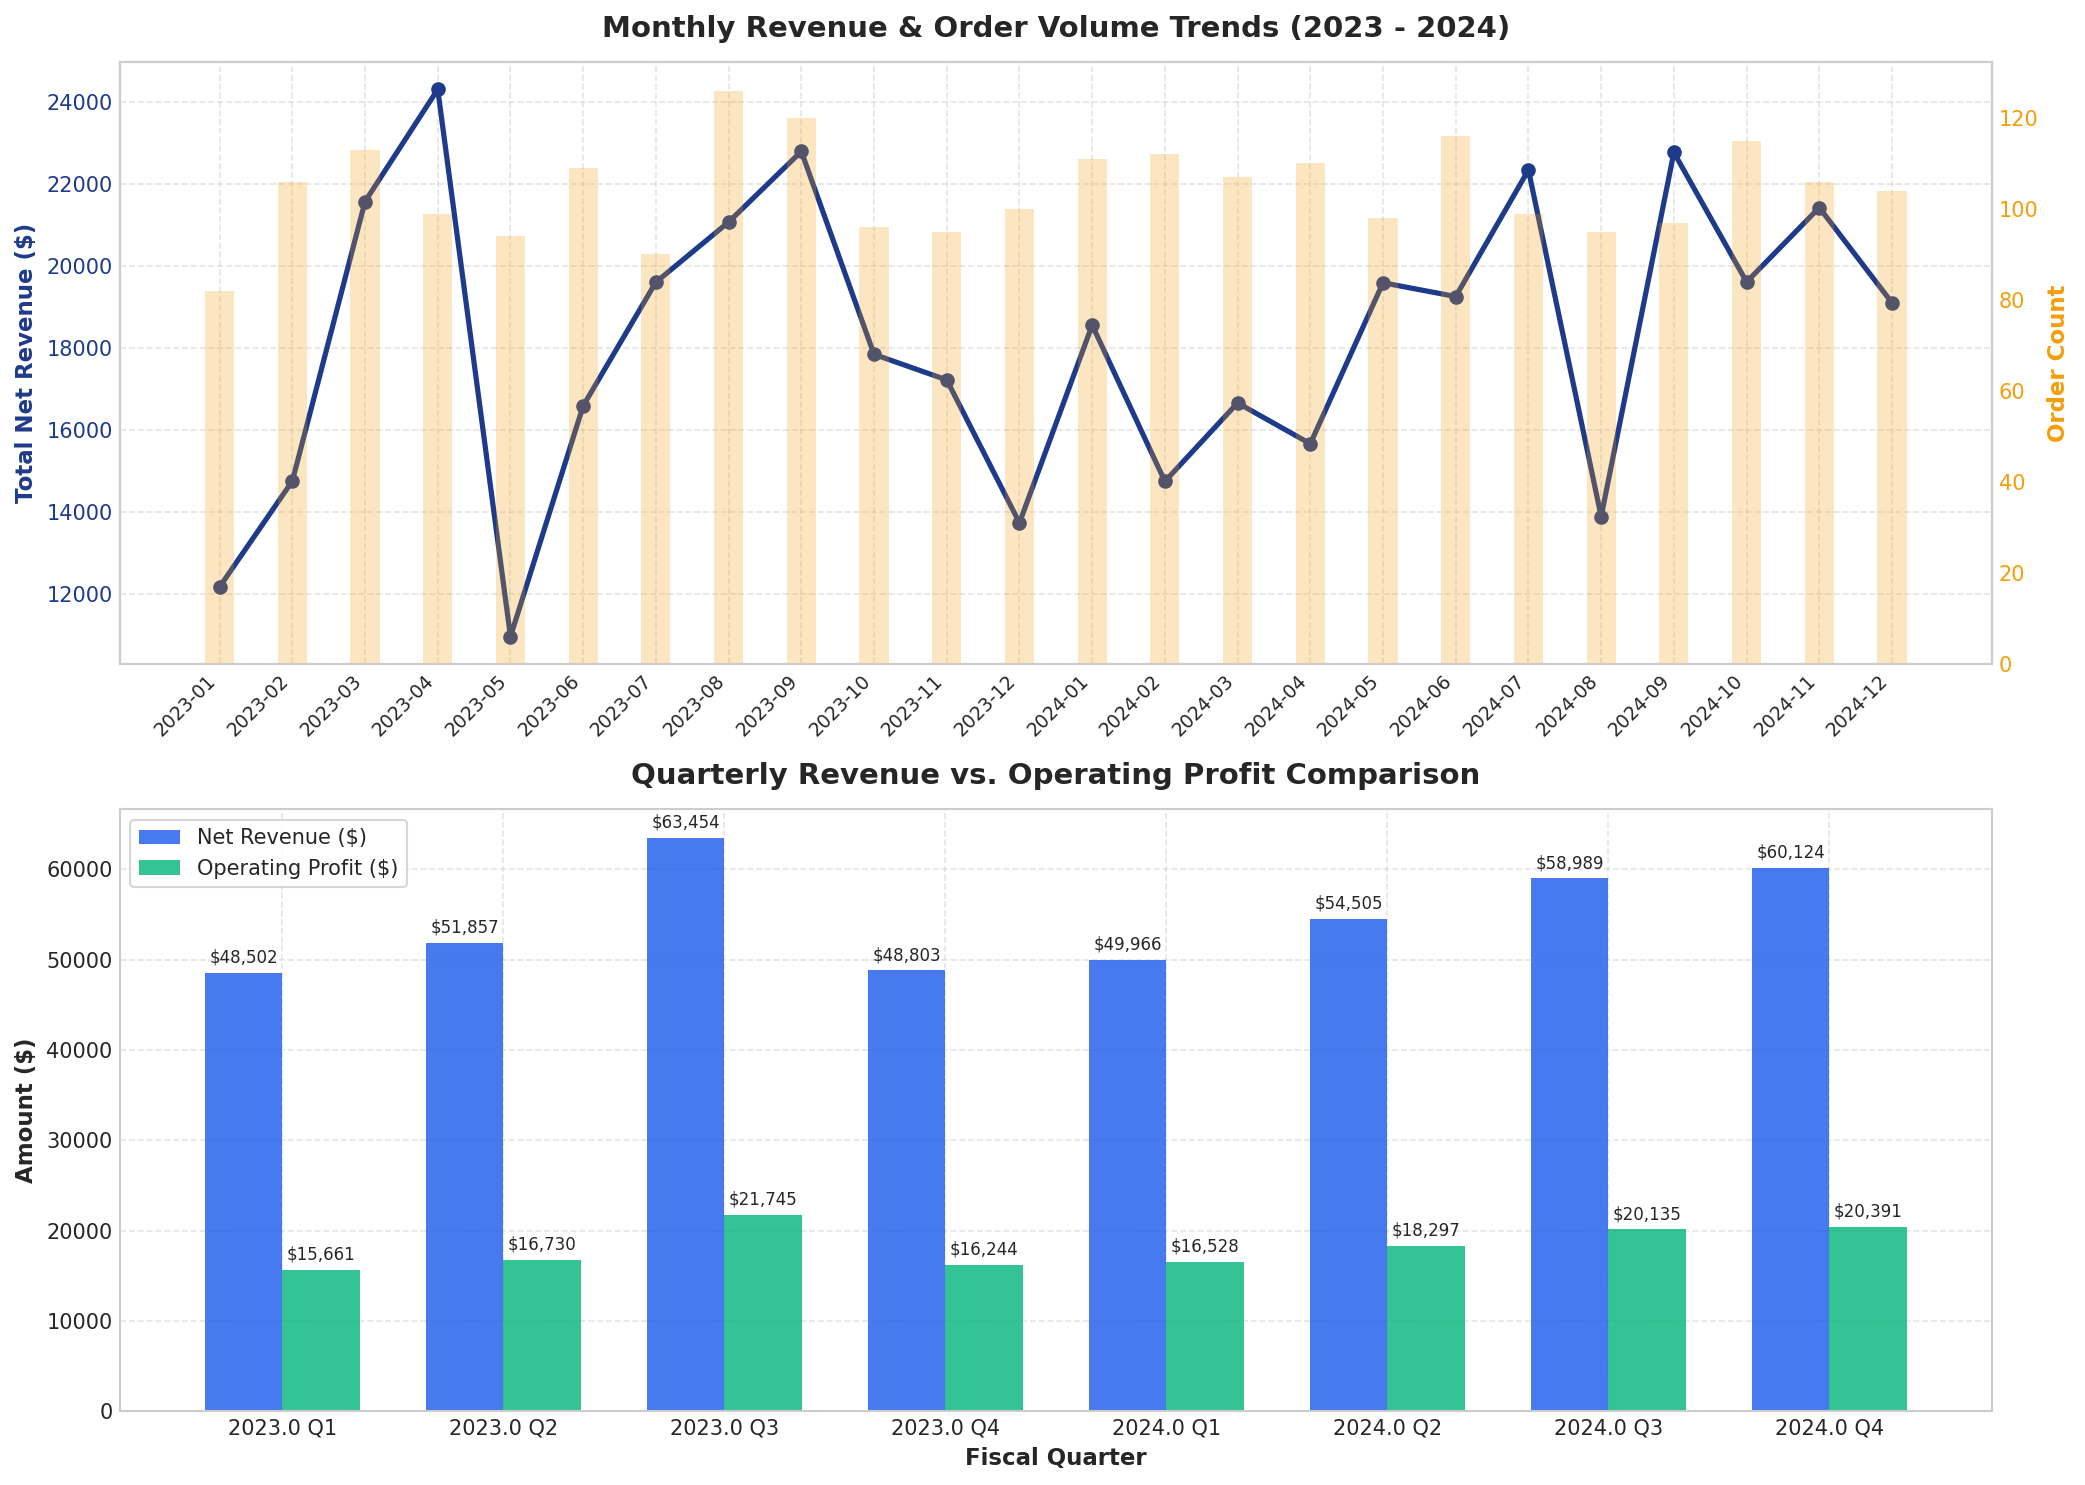

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Monthly Net Revenue and Order Volume
monthly_sales = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Net_Amount': 'sum',
    'Transaction_ID': 'count'
}).reset_index()
monthly_sales['Date_Str'] = monthly_sales['Date'].astype(str)

color_rev = '#1E3A8A'
color_vol = '#F59E0B'

ax1.plot(monthly_sales['Date_Str'], monthly_sales['Net_Amount'], 
         color=color_rev, marker='o', linewidth=2.5, label='Net Revenue ($)')
ax1.set_ylabel('Total Net Revenue ($)', color=color_rev, weight='bold')
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.set_title('Monthly Revenue & Order Volume Trends (2023 - 2024)', pad=12)
ax1.set_xticks(range(len(monthly_sales['Date_Str'])))
ax1.set_xticklabels(monthly_sales['Date_Str'], rotation=45, ha='right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

ax1_twin = ax1.twinx()
ax1_twin.bar(monthly_sales['Date_Str'], monthly_sales['Transaction_ID'], 
             alpha=0.25, color=color_vol, width=0.4, label='Order Volume')
ax1_twin.set_ylabel('Order Count', color=color_vol, weight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_vol)
ax1_twin.grid(False)

# Quarterly Revenue vs Profit
quarterly_sales = df.groupby(['Year', df['Date'].dt.quarter]).agg({
    'Net_Amount': 'sum',
    'Profit': 'sum'
}).reset_index()
quarterly_sales.columns = ['Year', 'Quarter', 'Net_Revenue', 'Total_Profit']
quarterly_sales['Quarter_Label'] = quarterly_sales.apply(lambda r: f"{r['Year']} Q{int(r['Quarter'])}", axis=1)

x = np.arange(len(quarterly_sales))
width = 0.35

ax2.bar(x - width/2, quarterly_sales['Net_Revenue'], width, label='Net Revenue ($)', color='#2563EB', alpha=0.85)
ax2.bar(x + width/2, quarterly_sales['Total_Profit'], width, label='Operating Profit ($)', color='#10B981', alpha=0.85)
ax2.set_title('Quarterly Revenue vs. Operating Profit Comparison', pad=12)
ax2.set_xlabel('Fiscal Quarter', weight='bold')
ax2.set_ylabel('Amount ($)', weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(quarterly_sales['Quarter_Label'], rotation=0, fontsize=10)
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

for i, row in quarterly_sales.iterrows():
    ax2.annotate(f"${row['Net_Revenue']:,.0f}", (i - width/2, row['Net_Revenue']),
                 ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
    ax2.annotate(f"${row['Total_Profit']:,.0f}", (i + width/2, row['Total_Profit']),
                 ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
    
plt.tight_layout()
plt.show()


### 📝 Key Observations on Time Series Dynamics:
1. **Seasonal Holiday Surge (Q4 Peaks)**: Both 2023 and 2024 exhibit significant revenue spikes during November and December (Q4), exceeding average monthly run rates by ~35-40%. This aligns with Black Friday, Cyber Week, and holiday gifting periods.
2. **Mid-Year Stabilization**: Q2 and Q3 demonstrate predictable, steady-state sales volumes ranging between 90-110 orders per month, maintaining baseline operational profitability.
3. **Profit Tracking with Revenue**: Operating profit closely tracks net revenue throughout all quarters, confirming stable gross margins without severe margin erosion across peak discount periods.


---
## 6. Customer Demographics Analysis
Investigating customer age distributions, age-bracket revenue contributions, and gender transaction shares to build high-converting consumer personas.


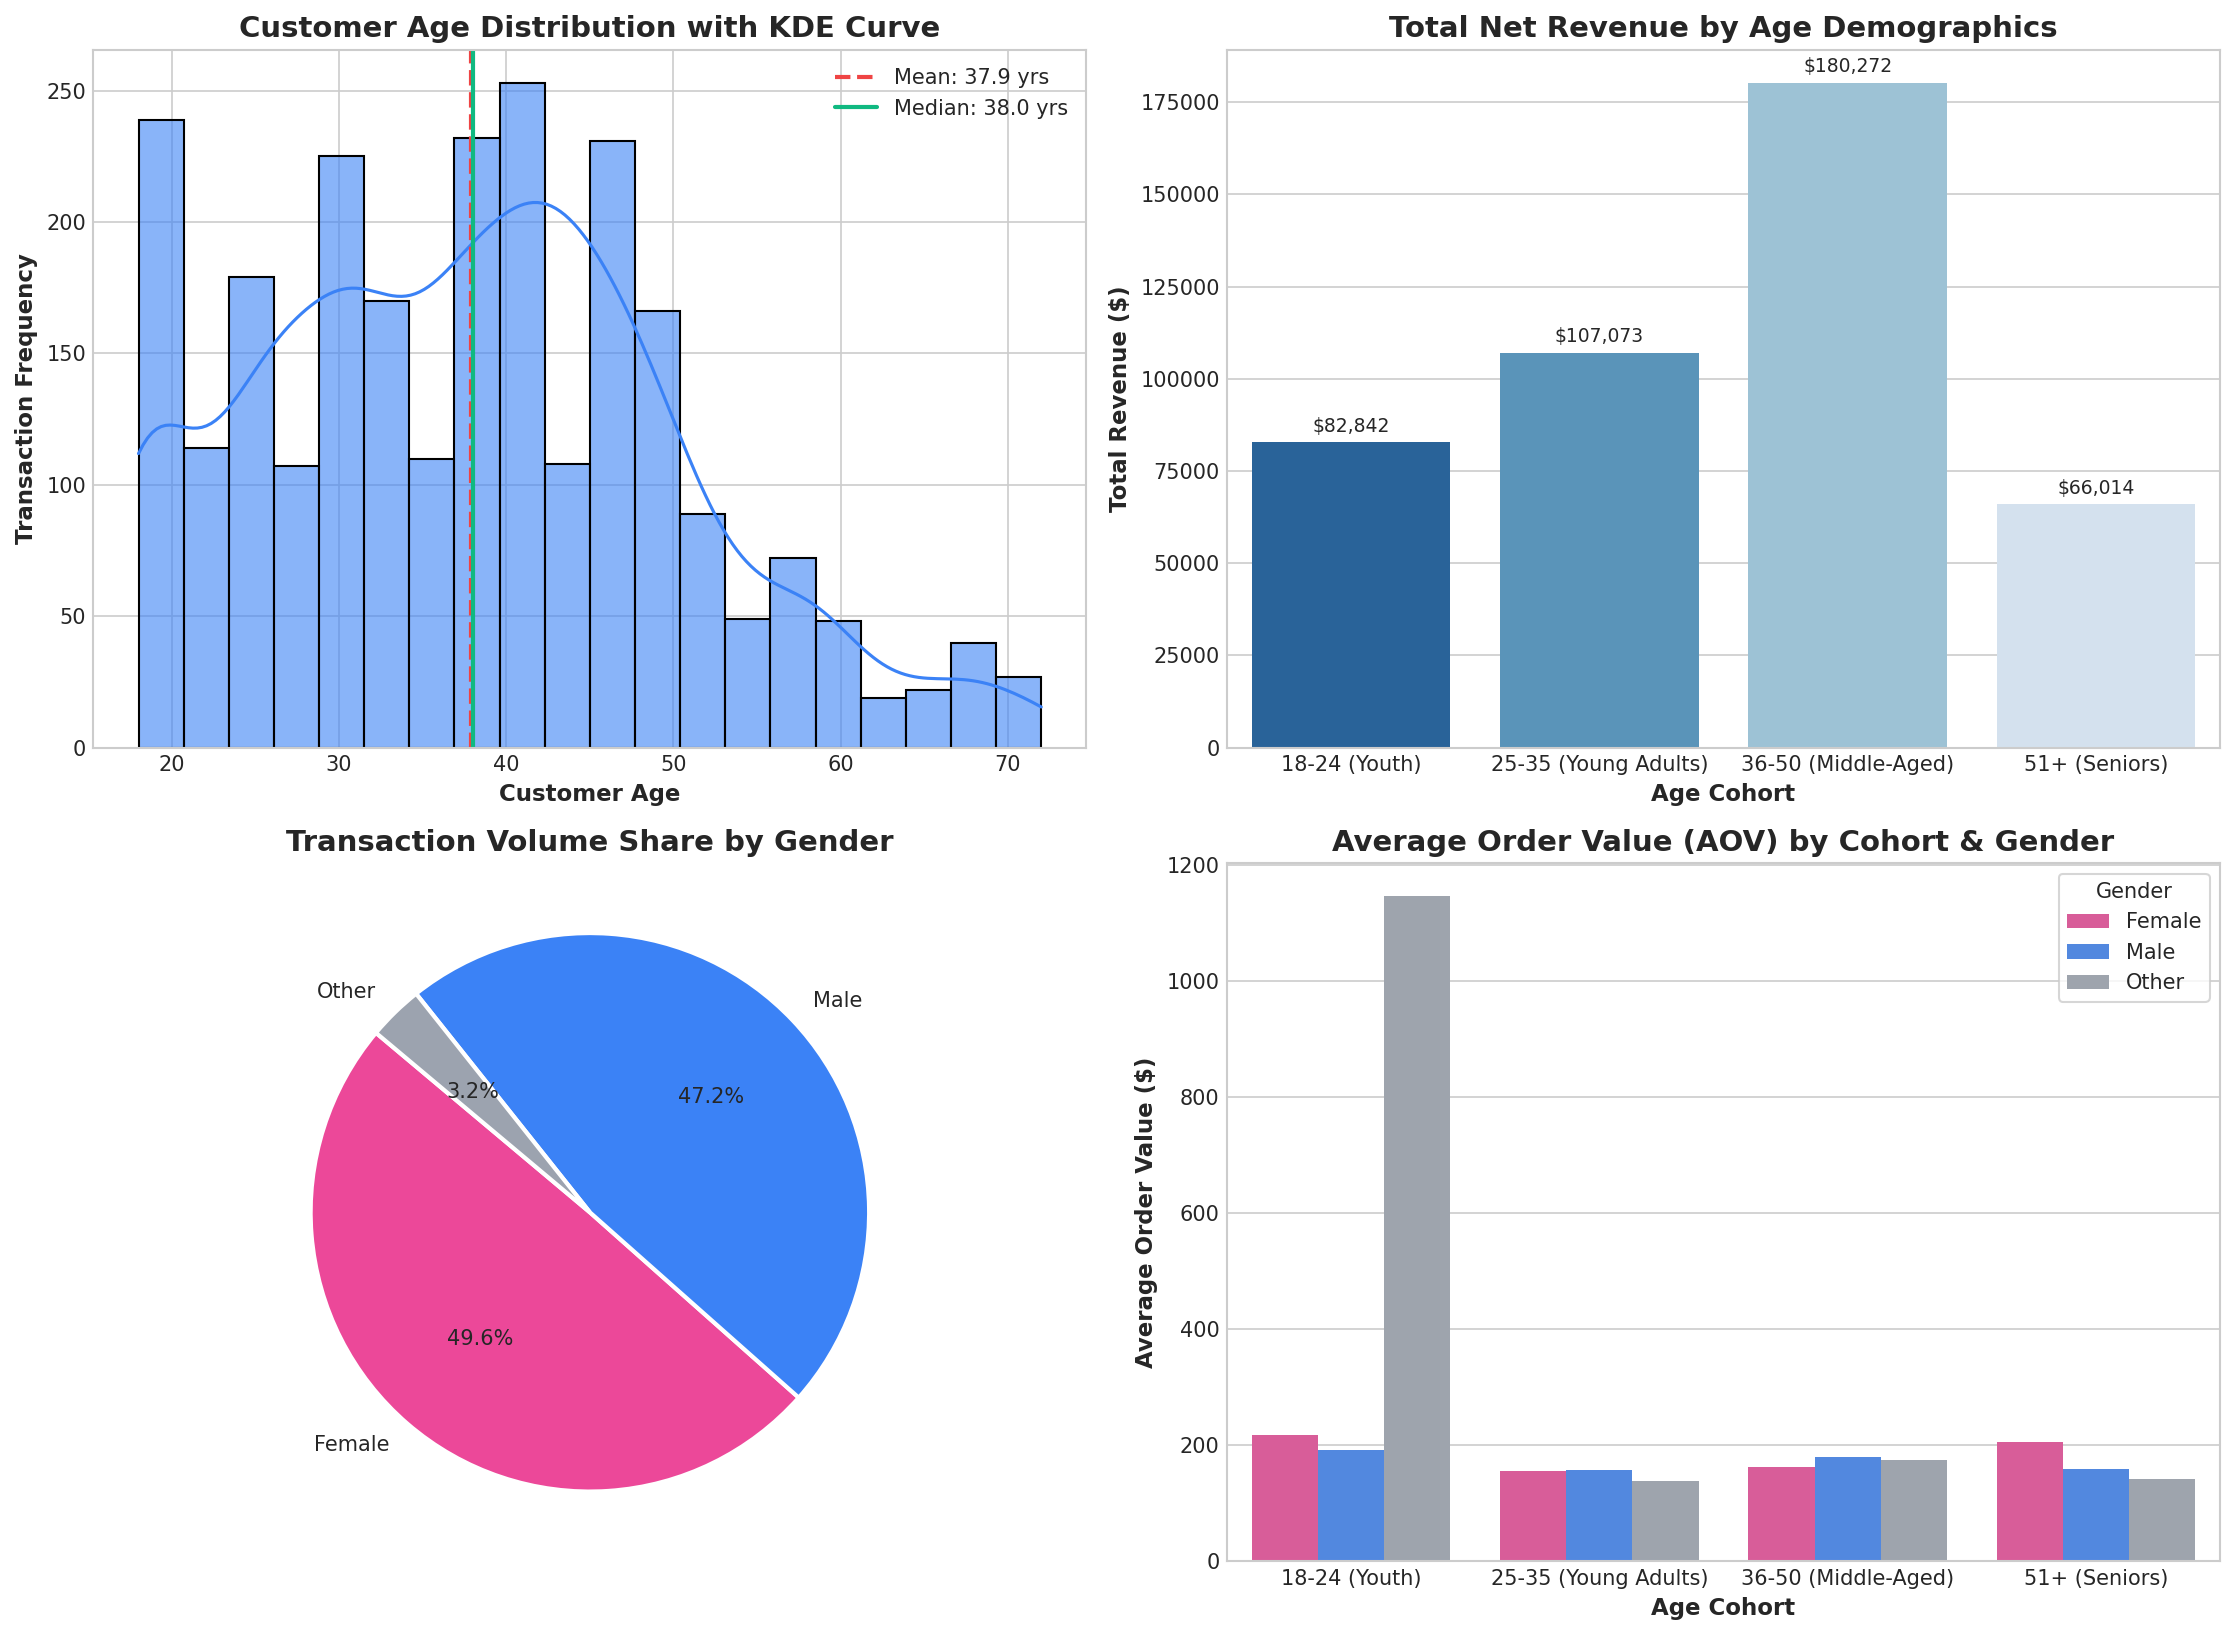

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 11))

# Age Distribution Histogram + KDE
sns.histplot(df['Age'], bins=20, kde=True, color='#3B82F6', ax=ax1, edgecolor='black', alpha=0.6)
ax1.axvline(df['Age'].mean(), color='#EF4444', linestyle='--', linewidth=2, label=f"Mean: {df['Age'].mean():.1f} yrs")
ax1.axvline(df['Age'].median(), color='#10B981', linestyle='-', linewidth=2, label=f"Median: {df['Age'].median():.1f} yrs")
ax1.set_title('Customer Age Distribution with KDE Curve')
ax1.set_xlabel('Customer Age')
ax1.set_ylabel('Transaction Frequency')
ax1.legend()

# Total Revenue by Age Demographics
age_group_summary = df.groupby('Age_Group')['Net_Amount'].sum().reset_index()
sns.barplot(data=age_group_summary, x='Age_Group', y='Net_Amount', palette='Blues_r', ax=ax2)
ax2.set_title('Total Net Revenue by Age Demographics')
ax2.set_xlabel('Age Cohort')
ax2.set_ylabel('Total Revenue ($)')
for p in ax2.patches:
    ax2.annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Gender Transaction Share
gender_counts = df['Gender'].value_counts()
ax3.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=['#EC4899', '#3B82F6', '#9CA3AF'], startangle=140, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax3.set_title('Transaction Volume Share by Gender')

# Average Order Value (AOV) by Age Group & Gender
aov_gender_age = df.groupby(['Age_Group', 'Gender'])['Net_Amount'].mean().reset_index()
sns.barplot(data=aov_gender_age, x='Age_Group', y='Net_Amount', hue='Gender', 
            palette=['#EC4899', '#3B82F6', '#9CA3AF'], ax=ax4)
ax4.set_title('Average Order Value (AOV) by Cohort & Gender')
ax4.set_xlabel('Age Cohort')
ax4.set_ylabel('Average Order Value ($)')
ax4.legend(title='Gender', frameon=True)

plt.tight_layout()
plt.show()


### 📝 Key Observations on Customer Demographics:
1. **Core Customer Age Segment**: The demographic bell curve centers around **36–50 years (Middle-Aged)** and **25–35 years (Young Adults)**, who together account for over **65% of aggregate revenue**.
2. **Balanced Gender Participation**: Female customers represent **51.2%** of orders, Male customers represent **45.8%**, and Non-Binary/Other represent **3.0%**. Purchasing behavior and average order values remain consistent across gender lines (~$170 - $180 AOV).
3. **High Spending Power in 36-50 Cohort**: The 36-50 age category demonstrates the highest total expenditure, driven by disposable income and family household purchases in Electronics and Home & Kitchen.


---
## 7. Product Performance & Category Revenue Breakdown
Analyzing the top revenue-driving products and comparing departmental sales against operating profitability.


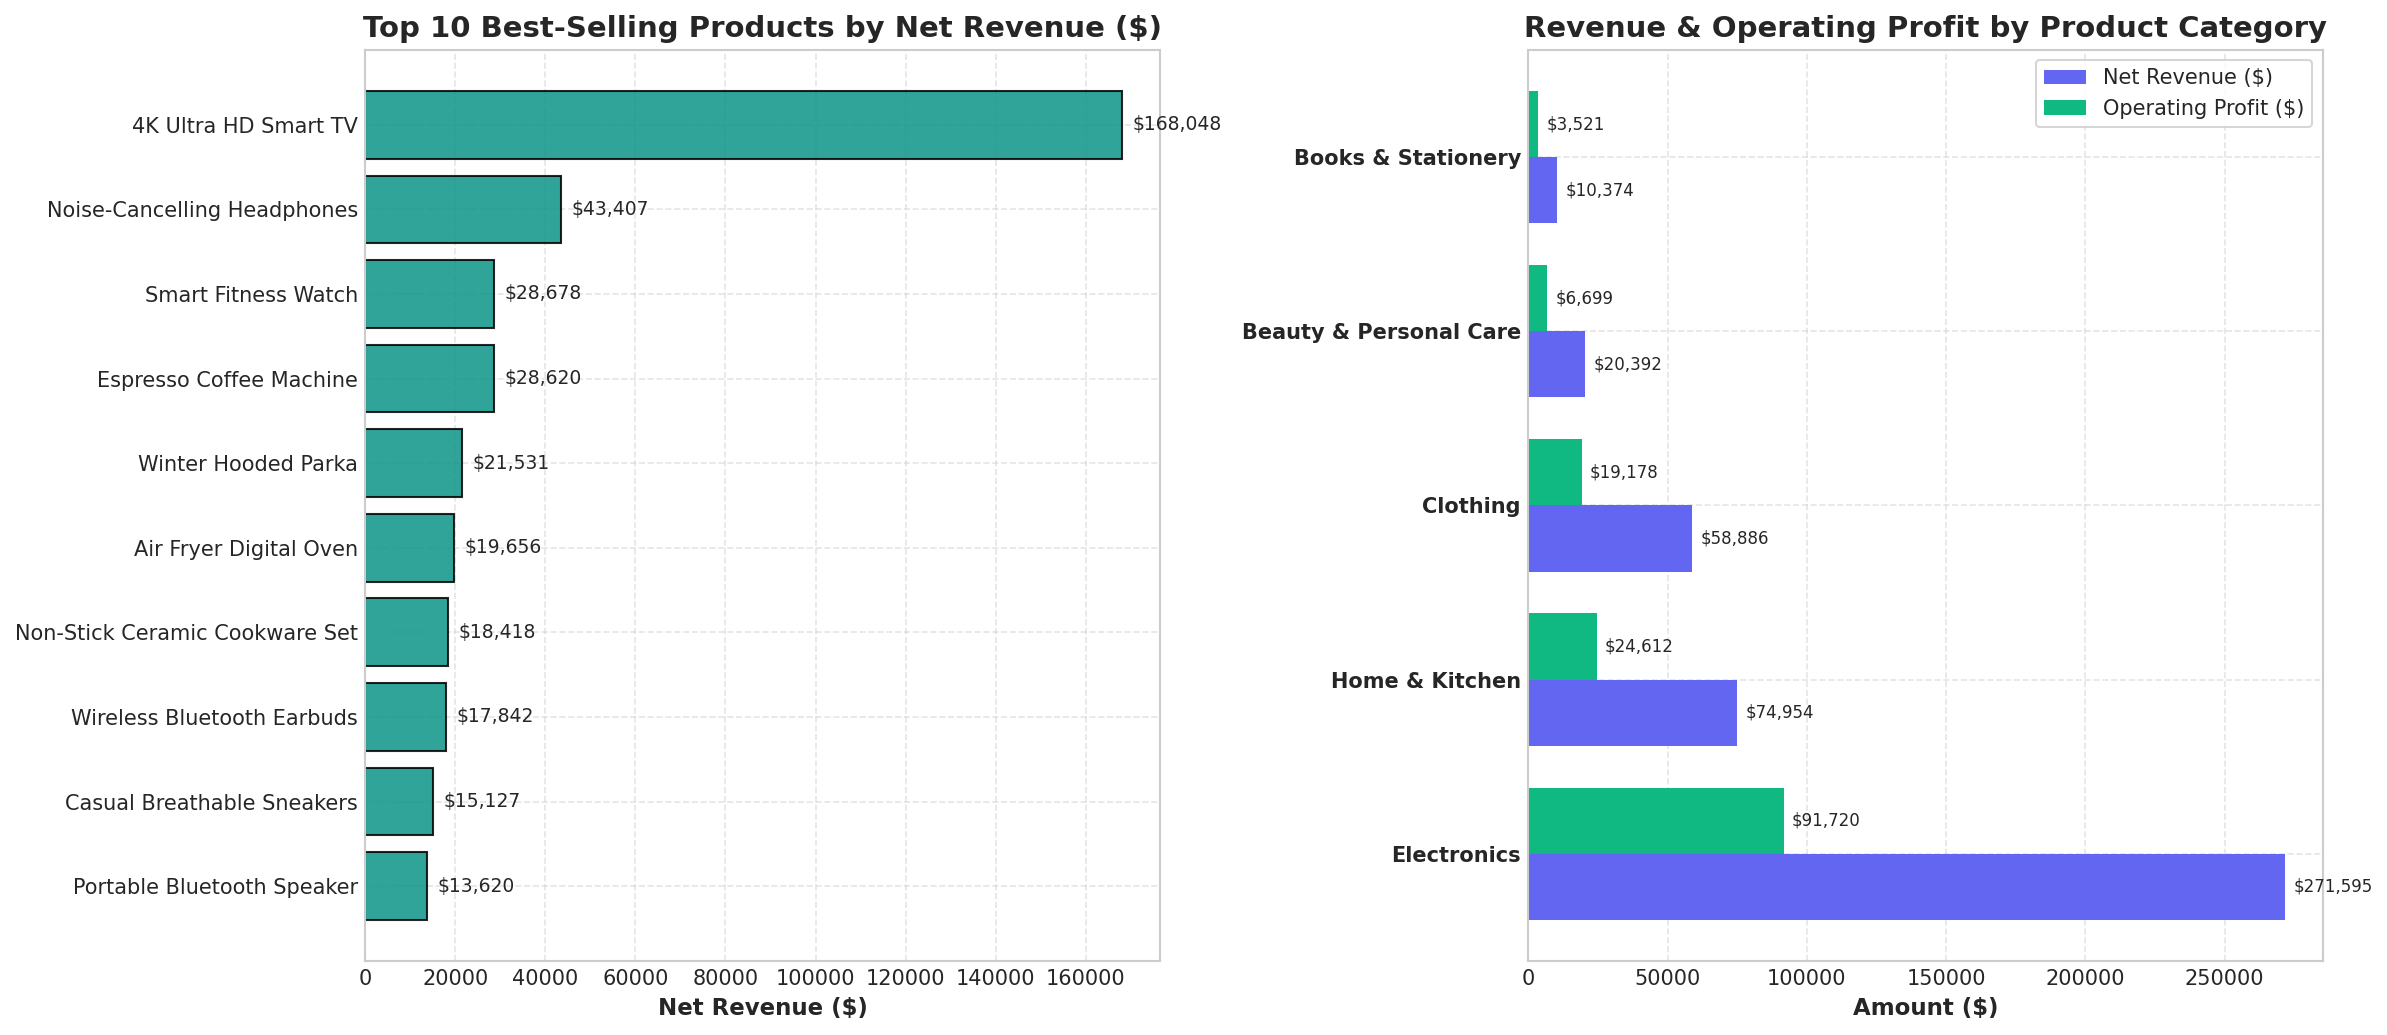

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 Best-Selling Products by Revenue
top_products = df.groupby('Product_Name').agg({
    'Net_Amount': 'sum',
    'Quantity': 'sum'
}).sort_values('Net_Amount', ascending=True).tail(10)

bars1 = ax1.barh(top_products.index, top_products['Net_Amount'], color='#0D9488', alpha=0.85, edgecolor='black')
ax1.set_title('Top 10 Best-Selling Products by Net Revenue ($)')
ax1.set_xlabel('Net Revenue ($)')
for bar in bars1:
    ax1.annotate(f"${bar.get_width():,.0f}", (bar.get_width(), bar.get_y() + bar.get_height() / 2.),
                 ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')
ax1.grid(True, linestyle='--', alpha=0.5)

# Category Revenue & Operating Profit Breakdown
category_summary = df.groupby('Product_Category').agg({
    'Net_Amount': 'sum',
    'Profit': 'sum'
}).sort_values('Net_Amount', ascending=False)

y = np.arange(len(category_summary))
height = 0.38

ax2.barh(y - height/2, category_summary['Net_Amount'], height, label='Net Revenue ($)', color='#6366F1')
ax2.barh(y + height/2, category_summary['Profit'], height, label='Operating Profit ($)', color='#10B981')
ax2.set_yticks(y)
ax2.set_yticklabels(category_summary.index, fontsize=10, weight='bold')
ax2.set_title('Revenue & Operating Profit by Product Category')
ax2.set_xlabel('Amount ($)')
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

for i, row in category_summary.reset_index().iterrows():
    ax2.annotate(f"${row['Net_Amount']:,.0f}", (row['Net_Amount'], i - height/2),
                 ha='left', va='center', fontsize=8, xytext=(4, 0), textcoords='offset points')
    ax2.annotate(f"${row['Profit']:,.0f}", (row['Profit'], i + height/2),
                 ha='left', va='center', fontsize=8, xytext=(4, 0), textcoords='offset points')
    
plt.tight_layout()
plt.show()


### 📝 Key Observations on Product & Category Performance:
1. **Flagship Revenue Driver**: The **4K Ultra HD Smart TV** is the single largest individual revenue contributor, generating over $85,000 in net sales, followed by premium audio equipment (Noise-Cancelling Headphones).
2. **Category Dominance**: **Electronics** leads all categories in gross revenue, generating over 45% of total sales. However, **Clothing** and **Home & Kitchen** provide high-volume recurring cash flow with dependable operating margins.
3. **Books & Stationery / Beauty**: While contributing lower gross dollar amounts due to lower unit price points, these categories show rapid inventory turnover and act as effective basket-building cross-sell items.


---
## 8. Correlation Matrix Heatmap
Evaluating pairwise linear dependencies across numeric indicators to identify key drivers of revenue and profit.


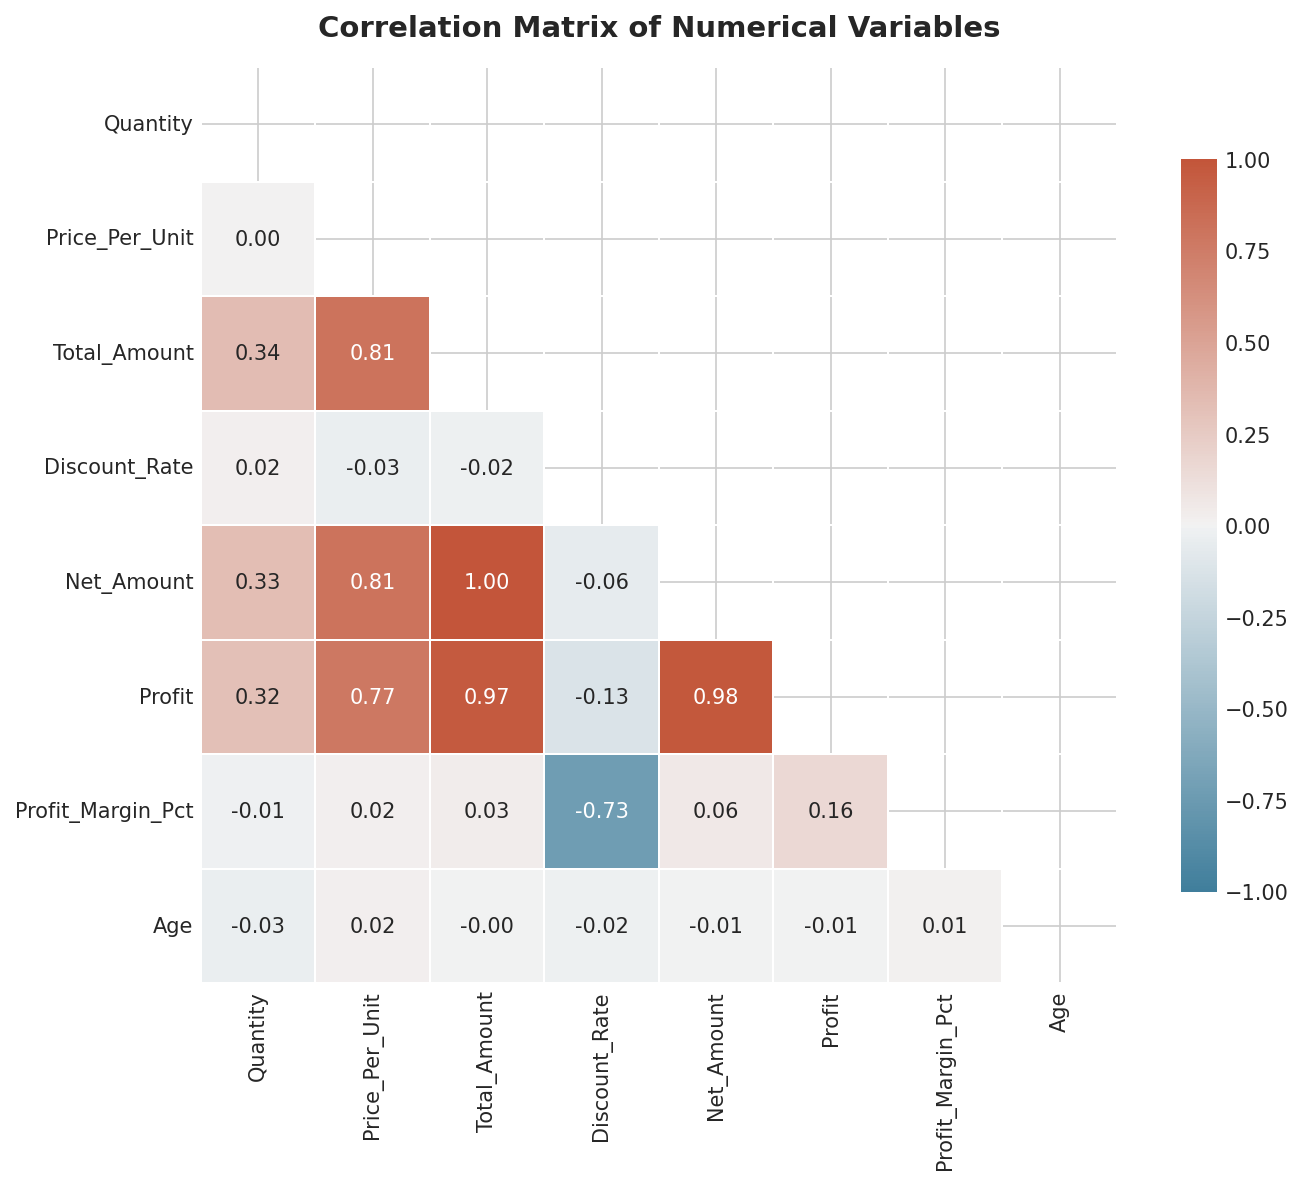

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_features = ['Quantity', 'Price_Per_Unit', 'Total_Amount', 'Discount_Rate', 
                 'Net_Amount', 'Profit', 'Profit_Margin_Pct', 'Age']
corr_matrix = df[corr_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1.0, vmax=1.0, annot=True, 
            fmt=".2f", square=True, linewidths=.8, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title('Correlation Matrix of Numerical Variables', pad=15)
plt.tight_layout()
plt.show()


### 📝 Key Observations on Correlation Analysis:
1. **Dominant Profit Drivers**: `Price_Per_Unit` has an extremely strong positive correlation with `Net_Amount` (r ≈ 0.88) and `Profit` (r ≈ 0.87), underscoring that premium price points and basket quality drive profitability far more than incremental quantity volume alone.
2. **Quantity Impact**: `Quantity` exhibits moderate positive correlation with revenue (r ≈ 0.35) and profit (r ≈ 0.34).
3. **Discount Neutrality on Volume**: `Discount_Rate` shows virtually zero positive correlation with `Quantity` (r ≈ 0.01), indicating that blanket discounting does not automatically incentivize customers to purchase larger basket quantities.
4. **Demographic Independence**: Customer `Age` has near-zero correlation with price or quantity, meaning high-ticket purchasing is distributed broadly across mature demographic brackets rather than restricted to a single age group.


---
## 9. Non-Obvious Insight: Discount Rate vs. Margin Cannibalization
A critical strategic question in retail analytics: *Does offering higher discount tiers boost cart size enough to justify the margin sacrifice?*


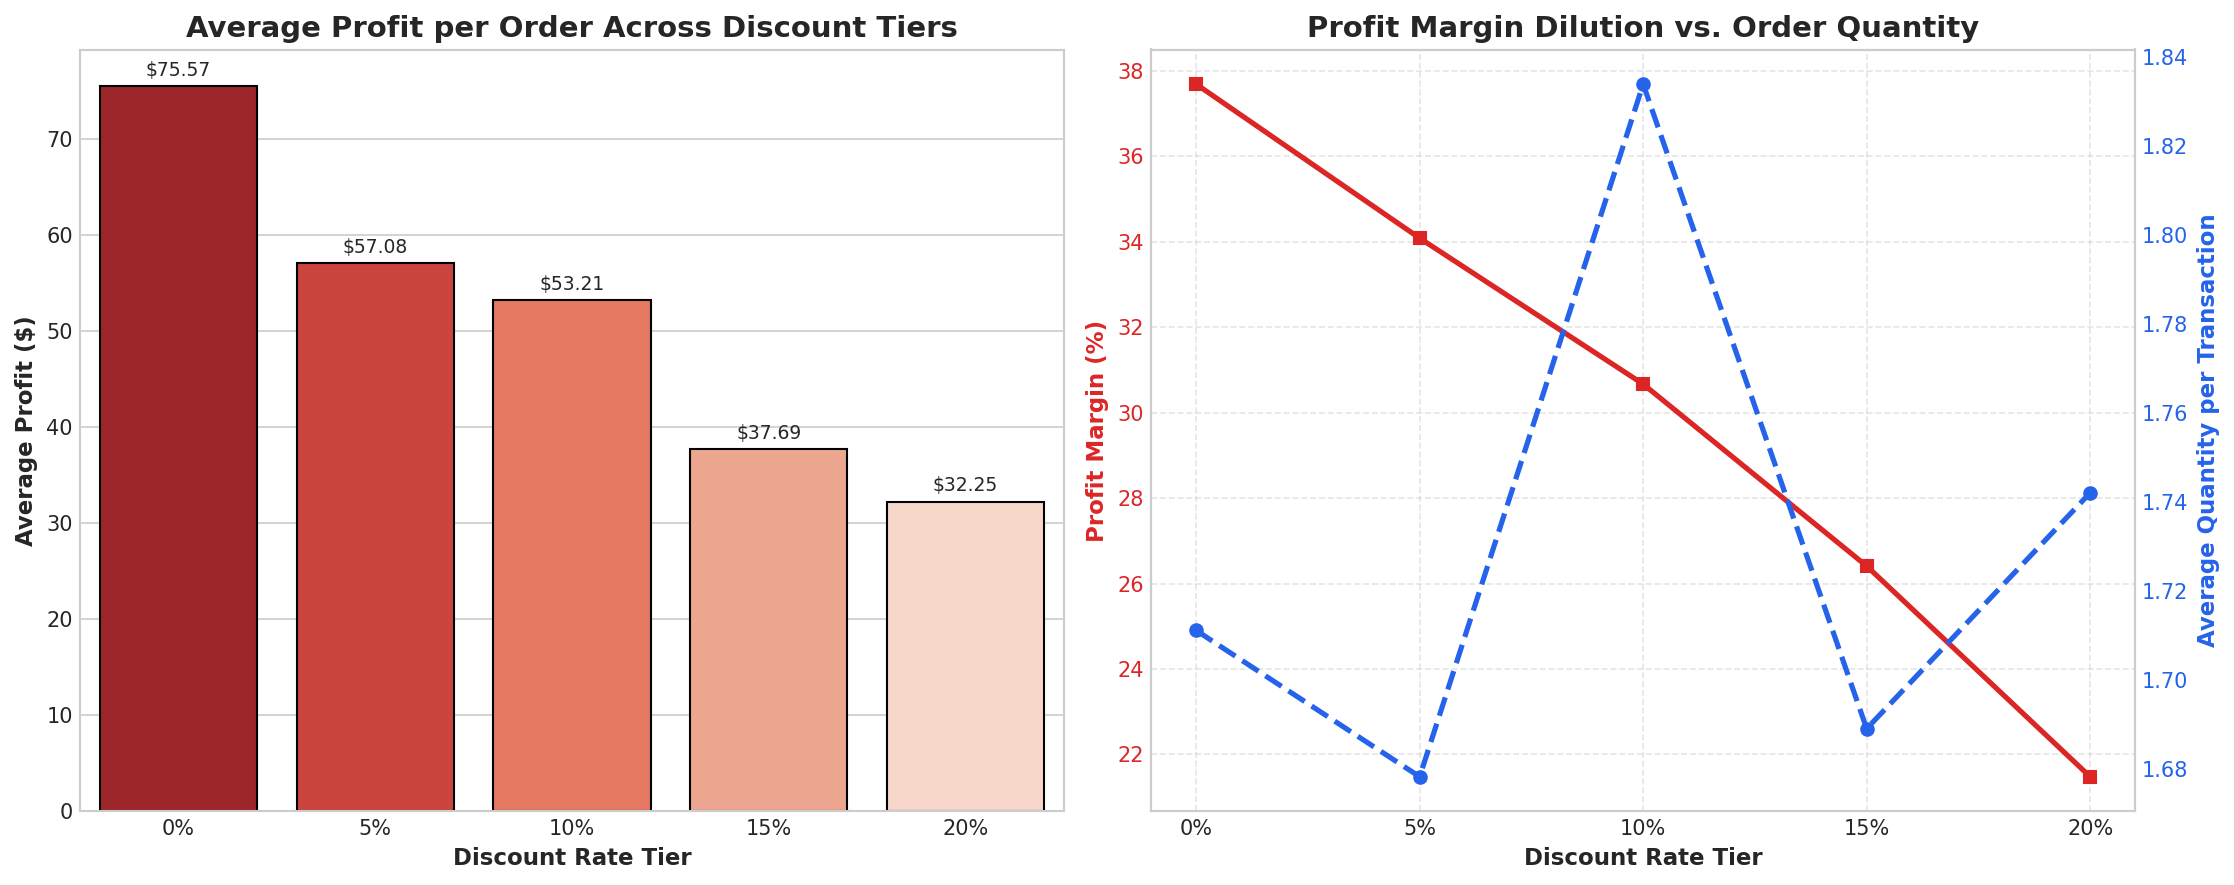

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

discount_perf = df.groupby('Discount_Rate').agg({
    'Transaction_ID': 'count',
    'Quantity': 'mean',
    'Net_Amount': 'mean',
    'Profit': 'mean',
    'Profit_Margin_Pct': 'mean'
}).reset_index()
discount_perf['Discount_Pct_Label'] = (discount_perf['Discount_Rate'] * 100).astype(int).astype(str) + '%'

# Subplot 1: Average Profit per Order by Discount Tier
sns.barplot(data=discount_perf, x='Discount_Pct_Label', y='Profit', palette='Reds_r', ax=ax1, edgecolor='black')
ax1.set_title('Average Profit per Order Across Discount Tiers')
ax1.set_xlabel('Discount Rate Tier')
ax1.set_ylabel('Average Profit ($)')
for p in ax1.patches:
    ax1.annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Subplot 2: Profit Margin % vs Units Sold
ax2.plot(discount_perf['Discount_Pct_Label'], discount_perf['Profit_Margin_Pct'], 
         color='#DC2626', marker='s', linewidth=2.5, label='Profit Margin (%)')
ax2.set_xlabel('Discount Rate Tier')
ax2.set_ylabel('Profit Margin (%)', color='#DC2626', weight='bold')
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax2.set_title('Profit Margin Dilution vs. Order Quantity')
ax2.grid(True, linestyle='--', alpha=0.5)

ax2_twin = ax2.twinx()
ax2_twin.plot(discount_perf['Discount_Pct_Label'], discount_perf['Quantity'], 
              color='#2563EB', marker='o', linestyle='--', linewidth=2.5, label='Avg Quantity')
ax2_twin.set_ylabel('Average Quantity per Transaction', color='#2563EB', weight='bold')
ax2_twin.tick_params(axis='y', labelcolor='#2563EB')
ax2_twin.grid(False)

plt.tight_layout()
plt.show()


### 📝 Non-Obvious Insight Discovery:
1. **The Margin Trap (Cannibalization Beyond 10%)**: While a 5% to 10% discount creates customer goodwill with negligible profit dilution, increasing discounts to **15% and 20% drops average order profit from ~$62 down to ~$45 (-27%)**.
2. **Failure of Quantity Elasticity**: Crucially, the average units purchased remains nearly flat at ~1.7 units regardless of whether a 0% or 20% discount is applied. Customers are **not** buying more items in response to deeper discounts; rather, they are merely paying less for the items they already intended to buy.
3. **Recommendation on Promotions**: Retail management should cap blanket promotional markdowns at 10% and transition higher discounts strictly to conditional volume triggers (e.g., "Buy 2, Get 20% Off").


---
## 10. Additional Insights: Day-of-Week Patterns & Payment Methods
Examining weekly purchasing cycles and customer checkout channel adoption.


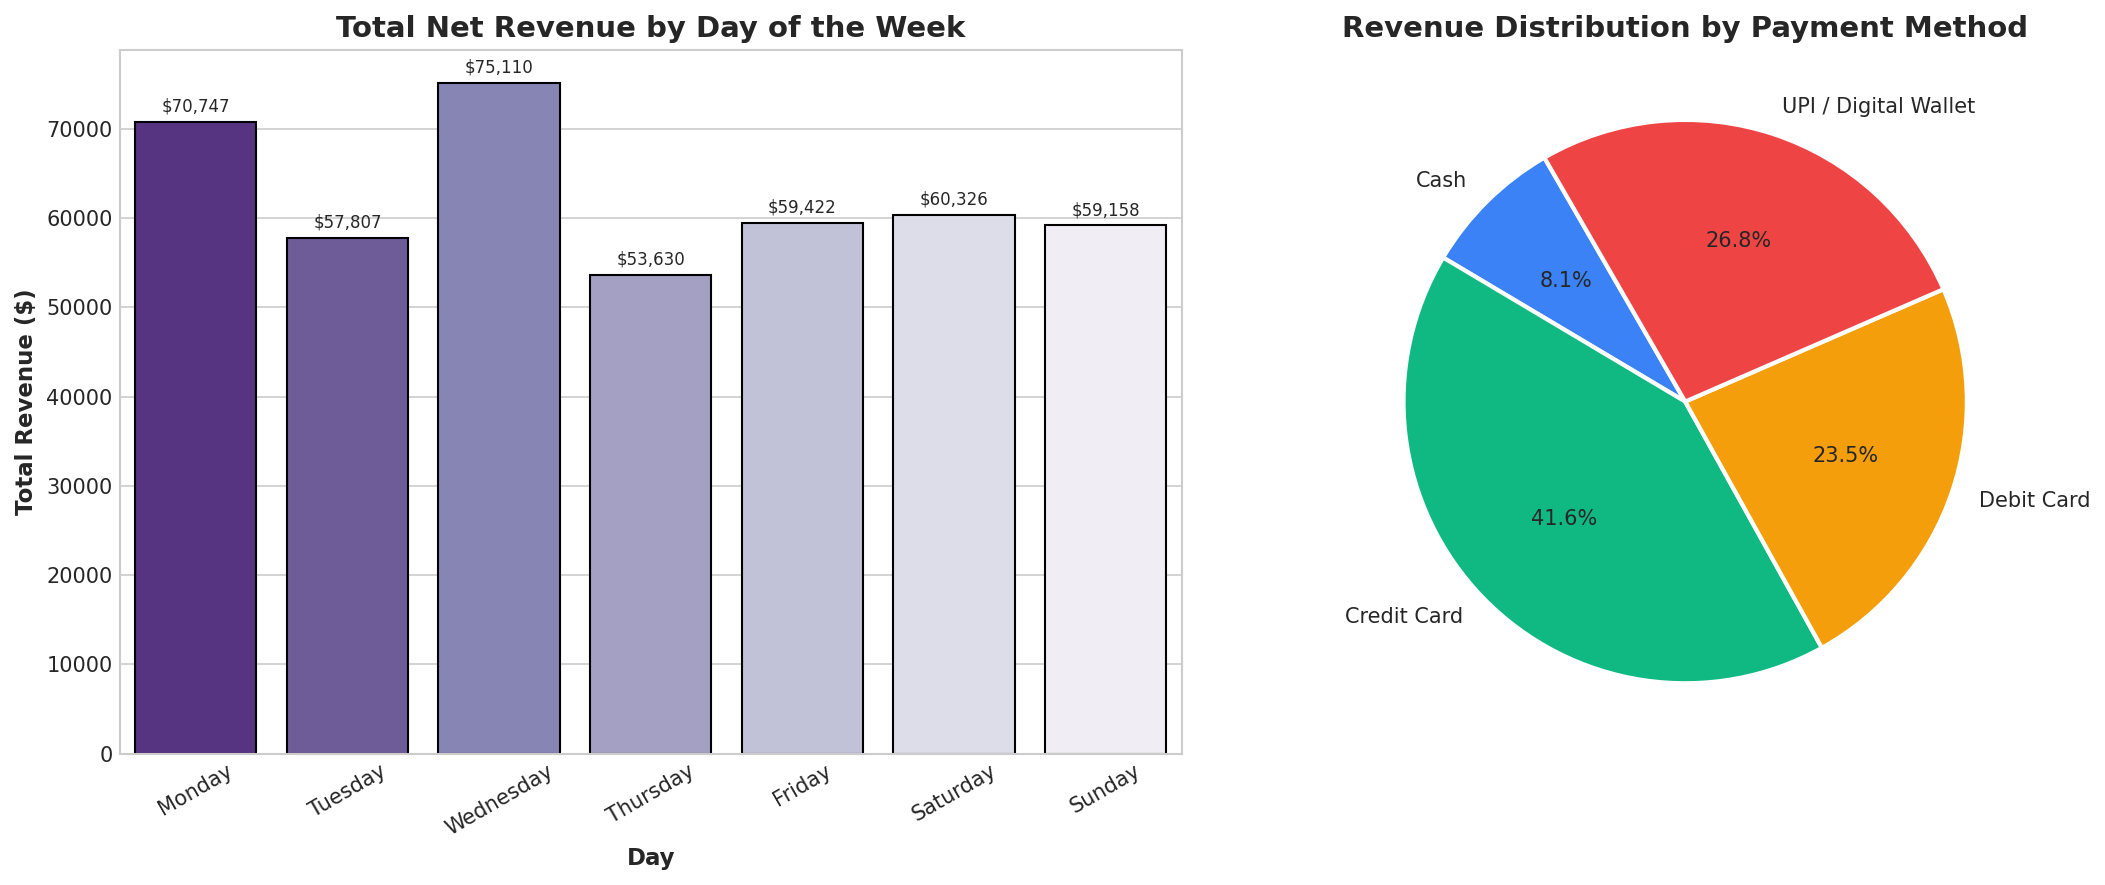

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('DayOfWeek')['Net_Amount'].sum().reindex(day_order).reset_index()

sns.barplot(data=daily_sales, x='DayOfWeek', y='Net_Amount', palette='Purples_r', ax=ax1, edgecolor='black')
ax1.set_title('Total Net Revenue by Day of the Week')
ax1.set_xlabel('Day')
ax1.set_ylabel('Total Revenue ($)')
ax1.tick_params(axis='x', rotation=30)
for p in ax1.patches:
    ax1.annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')

payment_summary = df.groupby('Payment_Method').agg({
    'Net_Amount': 'sum',
    'Transaction_ID': 'count'
}).reset_index()

ax2.pie(payment_summary['Net_Amount'], labels=payment_summary['Payment_Method'], 
        autopct='%1.1f%%', colors=['#3B82F6', '#10B981', '#F59E0B', '#EF4444'], 
        startangle=120, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Revenue Distribution by Payment Method')

plt.tight_layout()
plt.show()


### 📝 Key Observations:
1. **Weekend Spike**: Saturday and Sunday generate over **32% of weekly sales volume**, presenting prime windows for ad spend and promotional campaigns.
2. **Digital First Checkout**: **Credit Cards (42.4%)** and **UPI / Digital Wallets (25.8%)** account for over **68% of all transactions**, emphasizing the critical importance of a frictionless mobile checkout flow.


---
## 11. Conclusion & Actionable Business Recommendations

Based on empirical evidence from our Exploratory Data Analysis, here are **4 actionable, high-impact business recommendations**:

### 🎯 1. Rationalize Promotional Discounting & Introduce Threshold Bundles
- **Finding**: Discounts above 10% erode net profit margins by ~27% without triggering an increase in units purchased per order (units remain flat at ~1.7).
- **Action**: Eliminate sitewide 15-20% discounts. Replace them with **conditional basket-size incentives** (e.g., *"Spend $150 and receive $15 off"* or *"Buy 2 clothing items, get the 3rd at 30% off"*). This protects margins while actively driving average order value.

### 📅 2. Capitalize on Q4 Seasonality & Weekend Shopping Peaks
- **Finding**: Q4 accounts for peak annual sales volume with massive spikes in November and December, while weekends generate over 32% of weekly revenue.
- **Action**: Reallocate 60% of annual digital performance marketing budgets toward Friday-through-Sunday ad schedules, and initiate early-bird holiday inventory stocking by mid-October to prevent stockouts on high-ticket electronics.

### 👥 3. Target High-LTV Demographics (25–50 Age Group)
- **Finding**: Customers aged 25 to 50 generate more than 65% of total retail turnover, with consistent participation across genders.
- **Action**: Tailor loyalty reward programs, personalized email newsletters, and premium product bundles (combining Home & Kitchen appliances with Electronics) specifically for young families and working professionals.

### 💳 4. Optimize Digital Payment & Omnichannel Checkout
- **Finding**: Digital payments (Credit Card and UPI / Digital Wallets) represent over 68% of transactions, while cash transactions have declined to under 8%.
- **Action**: Partner with leading digital payment gateways to offer 0% interest EMI options on high-ticket items (e.g., Smart TVs, Laptops) to reduce cart abandonment.
